# Week 4 Lab — Fine-Tuning With Only 5,000 Labelled Photos

**Course:** Image and Scene Recognition — Week 4 Lab  
**Dataset:** CIFAR-10  
**Framework:** PyTorch  
**Goal:** Build, train, evaluate, and diagnose a CNN from scratch.
**Model:** ImageNet

> **Student:** Ghazanfar Aaila
> **Student ID:** 2417292

### Problem
Build a low-cost roadside smart-camera recogniser using only 5,000 labelled images (500 per class) and determine whether transfer learning can provide reliable scene classification:
1. Scratch CNN  Train the Week 3 SceneCNN from random weights.
2. eature extraction  Use a frozen pretrained ResNet-18 backbone with a new classifier head.
3. Fine-tune the last ResNet-18 block using augmentation, dropout, and weight decay.
4. Compare the three models on exactly the same 5,000 images and determine whether the system can reliably distinguish scenes such as a deer from a truck.



In [2]:
import sys
import torch
import torchvision
import matplotlib
import matplotlib.pyplot as plt

print("Python:", sys.version)
print("PyTorch:", torch.__version__)
print("torchvision:", torchvision.__version__)
print("Matplotlib:", matplotlib.__version__)
print("CUDA available:", torch.cuda.is_available())

Python: 3.14.7 | packaged by Anaconda, Inc. | (main, Aug 14 2026, 10:12:46) [MSC v.1942 64 bit (AMD64)]
PyTorch: 2.14.1+cpu
torchvision: 0.29.1+cpu
Matplotlib: 3.11.2
CUDA available: False


In [3]:
import os, sys, time, copy, random
import numpy as np
import matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.nn.functional as F
import torchvision, torchvision.transforms as T
from torch.utils.data import DataLoader, Subset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

FAST = device.type != "cpu"
EP_SCRATCH, EP_HEAD, EP_FT = (10, 5, 6) if FAST else (5, 3, 3)

print("PyTorch:", torch.__version__, "| torchvision:", torchvision.__version__)
print("Training on:", device, "| epochs (scratch/head/fine-tune):", EP_SCRATCH, EP_HEAD, EP_FT)

PyTorch: 2.14.1+cpu | torchvision: 0.29.1+cpu
Training on: cpu | epochs (scratch/head/fine-tune): 5 3 3


In [4]:
CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck']

CIFAR_MEAN, CIFAR_STD = (0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)
IMNET_MEAN, IMNET_STD = (0.485, 0.456, 0.406), (0.229, 0.224, 0.225)

IMG = 64
root = "./data"

# ResNet-18 expects ImageNet preprocessing
eval_tf = T.Compose([
    T.Resize(IMG),
    T.ToTensor(),
    T.Normalize(IMNET_MEAN, IMNET_STD)
])

# Augmentation used later during fine-tuning
aug_tf = T.Compose([
    T.RandomResizedCrop(IMG, scale=(0.7, 1.0), ratio=(0.9, 1.1)),
    T.RandomHorizontalFlip(),
    T.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.3
    ),
    T.ToTensor(),
    T.Normalize(IMNET_MEAN, IMNET_STD)
])

# Load CIFAR-10
ds_eval = torchvision.datasets.CIFAR10(
    root,
    train=True,
    download=True,
    transform=eval_tf
)

ds_aug = torchvision.datasets.CIFAR10(
    root,
    train=True,
    download=False,
    transform=aug_tf
)

ds_test = torchvision.datasets.CIFAR10(
    root,
    train=False,
    download=True,
    transform=eval_tf
)

# Create balanced 5,000-image training set
# and 1,000-image validation set
targets = np.array(ds_eval.targets)

rng = np.random.default_rng(SEED)

train_idx, val_idx = [], []

for c in range(10):
    idx = rng.permutation(np.where(targets == c)[0])

    train_idx += idx[:500].tolist()
    val_idx += idx[500:600].tolist()

# Verify there is no train/validation overlap
assert len(set(train_idx) & set(val_idx)) == 0, \
    "LEAKAGE: train and val overlap!"

print("train:", len(train_idx),
      "| val:", len(val_idx),
      "| test:", len(ds_test))

print("images per class in train:",
      np.bincount(targets[train_idx]))

def make_loader(ds, idx, shuffle, bs=64):
    return DataLoader(
        Subset(ds, idx),
        batch_size=bs,
        shuffle=shuffle,
        num_workers=2
    )

train_plain = make_loader(
    ds_eval, train_idx, True
)

train_aug = make_loader(
    ds_aug, train_idx, True
)

val_loader = make_loader(
    ds_eval, val_idx, False, 128
)

test_loader = DataLoader(
    ds_test,
    batch_size=128,
    shuffle=False,
    num_workers=2
)

100%|██████████| 170M/170M [19:12<00:00, 148kB/s]    


train: 5000 | val: 1000 | test: 10000
images per class in train: [500 500 500 500 500 500 500 500 500 500]


In [5]:
ce = nn.CrossEntropyLoss()

def trainable(m):
    return sum(
        p.numel()
        for p in m.parameters()
        if p.requires_grad
    )


def set_train_mode(model):
    model.train()

    for m in model.modules():
        if (
            isinstance(m, nn.BatchNorm2d)
            and not any(p.requires_grad for p in m.parameters())
        ):
            m.eval()


def run_epoch(model, loader, optimizer=None, criterion=ce):
    training = optimizer is not None

    if training:
        set_train_mode(model)
    else:
        model.eval()

    total_loss = 0.0
    correct = 0
    n = 0

    with torch.set_grad_enabled(training):

        for x, y in loader:

            x, y = x.to(device), y.to(device)

            out = model(x)
            loss = criterion(out, y)

            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * x.size(0)
            correct += (out.argmax(1) == y).sum().item()
            n += x.size(0)

    return total_loss / n, correct / n


def fit(
    model,
    optimizer,
    train_loader,
    val_loader,
    epochs,
    tag,
    criterion=ce
):

    hist = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    for ep in range(1, epochs + 1):

        t0 = time.time()

        tl, ta = run_epoch(
            model,
            train_loader,
            optimizer,
            criterion
        )

        vl, va = run_epoch(
            model,
            val_loader
        )

        for k, v in zip(
            hist,
            (tl, vl, ta, va)
        ):
            hist[k].append(v)

        print(
            f"[{tag}] epoch {ep}/{epochs} "
            f"| train {ta:.1%} (loss {tl:.3f}) "
            f"| val {va:.1%} (loss {vl:.3f}) "
            f"| {time.time() - t0:.0f}s"
        )

    return hist


@torch.no_grad()
def predict_all(model, loader):

    model.eval()

    probs = []
    ys = []

    for x, y in loader:

        probs.append(
            F.softmax(
                model(x.to(device)),
                dim=1
            ).cpu()
        )

        ys.append(y)

    return torch.cat(probs), torch.cat(ys)


def confusion(ys, preds, n=10):

    cm = np.zeros(
        (n, n),
        dtype=int
    )

    for t, p_ in zip(
        ys.numpy(),
        preds.numpy()
    ):
        cm[t, p_] += 1

    return cm

In [6]:
class SceneCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.classifier(
            self.features(x)
        )


# Week 3 normalization
w3_tf = T.Compose([
    T.ToTensor(),
    T.Normalize(CIFAR_MEAN, CIFAR_STD)
])


# Load CIFAR-10 using the Week 3 preprocessing
w3_train = torchvision.datasets.CIFAR10(
    root,
    train=True,
    download=False,
    transform=w3_tf
)

w3_test = torchvision.datasets.CIFAR10(
    root,
    train=False,
    download=False,
    transform=w3_tf
)


# Use the same 5,000/1,000 split
w3_train_loader = make_loader(
    w3_train,
    train_idx,
    True
)

w3_val_loader = make_loader(
    w3_train,
    val_idx,
    False,
    128
)

w3_test_loader = DataLoader(
    w3_test,
    batch_size=128,
    shuffle=False,
    num_workers=2
)


# Check whether the Week 3 trained model exists
if os.path.exists("scene_cnn_week3.pth"):

    old = SceneCNN().to(device)

    old.load_state_dict(
        torch.load(
            "scene_cnn_week3.pth",
            map_location=device
        )
    )

    _, old_acc = run_epoch(
        old,
        w3_test_loader
    )

    print(
        f"Week 3 model (45,000 training images) "
        f"test accuracy: {old_acc:.1%}"
    )

else:

    print(
        "scene_cnn_week3.pth not found: "
        "skipping (your Week 3 result was roughly 70-75%)"
    )


# Train a new scratch CNN using only 5,000 images
scratch = SceneCNN().to(device)

opt = torch.optim.SGD(
    scratch.parameters(),
    lr=0.01,
    momentum=0.9
)

hist_scratch = fit(
    scratch,
    opt,
    w3_train_loader,
    w3_val_loader,
    EP_SCRATCH,
    "scratch"
)

scene_cnn_week3.pth not found: skipping (your Week 3 result was roughly 70-75%)
[scratch] epoch 1/5 | train 16.1% (loss 2.229) | val 23.9% (loss 2.080) | 10s
[scratch] epoch 2/5 | train 30.3% (loss 1.925) | val 30.6% (loss 1.893) | 10s
[scratch] epoch 3/5 | train 37.3% (loss 1.719) | val 39.4% (loss 1.665) | 10s
[scratch] epoch 4/5 | train 43.5% (loss 1.559) | val 44.3% (loss 1.541) | 10s
[scratch] epoch 5/5 | train 47.2% (loss 1.444) | val 50.7% (loss 1.380) | 10s


In [7]:
def make_resnet(dropout=0.0):
    # Load ImageNet-pretrained ResNet-18
    m = torchvision.models.resnet18(
        weights="IMAGENET1K_V1"
    )

    # Freeze the pretrained backbone
    for p in m.parameters():
        p.requires_grad = False

    # Replace the original ImageNet classifier
    m.fc = nn.Sequential(
        nn.Dropout(dropout),
        nn.Linear(m.fc.in_features, 10)
    )

    return m.to(device)


# Create feature-extraction model
fe_model = make_resnet(dropout=0.0)


# Count parameters
total = sum(
    p.numel()
    for p in fe_model.parameters()
)

trainable_params = trainable(fe_model)

print(
    f"Total parameters    : {total:,}"
)

print(
    f"Trainable parameters: {trainable_params:,} "
    f"({trainable_params / total:.2%})"
)

print("Head:", fe_model.fc)


# Train only the new classification head
opt = torch.optim.AdamW(
    [
        p for p in fe_model.parameters()
        if p.requires_grad
    ],
    lr=1e-3,
    weight_decay=1e-2
)


hist_fe = fit(
    fe_model,
    opt,
    train_plain,
    val_loader,
    EP_HEAD,
    "feature-extraction"
)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\kdu/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 106MB/s] 


Total parameters    : 11,181,642
Trainable parameters: 5,130 (0.05%)
Head: Sequential(
  (0): Dropout(p=0.0, inplace=False)
  (1): Linear(in_features=512, out_features=10, bias=True)
)
[feature-extraction] epoch 1/3 | train 53.4% (loss 1.337) | val 66.4% (loss 1.005) | 13s
[feature-extraction] epoch 2/3 | train 70.3% (loss 0.855) | val 69.2% (loss 0.920) | 13s
[feature-extraction] epoch 3/3 | train 74.9% (loss 0.748) | val 69.7% (loss 0.857) | 16s


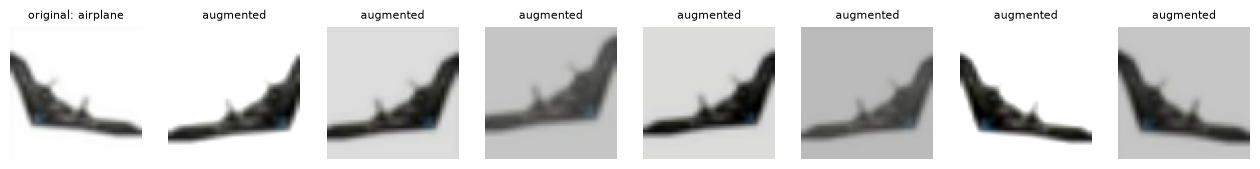

In [8]:
def denorm(x):
    m = torch.tensor(IMNET_MEAN).view(3, 1, 1)
    s = torch.tensor(IMNET_STD).view(3, 1, 1)

    return (x * s + m).clamp(0, 1)


# Load raw CIFAR-10 images without transformations
raw = torchvision.datasets.CIFAR10(
    root,
    train=True,
    download=False
)

# Select one training image
img, label = raw[train_idx[3]]


# Display original + 7 augmented versions
fig, axes = plt.subplots(
    1,
    8,
    figsize=(16, 2.4)
)

# Original image
axes[0].imshow(
    img.resize((IMG, IMG))
)

axes[0].set_title(
    "original: " + CLASSES[label],
    fontsize=8
)


# Augmented versions
for ax in axes[1:]:

    ax.imshow(
        denorm(
            aug_tf(img)
        ).permute(1, 2, 0)
    )

    ax.set_title(
        "augmented",
        fontsize=8
    )


# Remove axes
for ax in axes:
    ax.axis("off")

plt.show()

In [9]:
# Start from the feature-extraction model
ft_model = copy.deepcopy(fe_model)


# Unfreeze the final ResNet residual block
for p in ft_model.layer4.parameters():
    p.requires_grad = True


# Increase dropout in the classification head
ft_model.fc[0].p = 0.3


# Discriminative learning rates:
# - smaller LR for pretrained layer4
# - larger LR for the newly learned classifier
opt = torch.optim.AdamW(
    [
        {
            "params": ft_model.layer4.parameters(),
            "lr": 1e-4
        },
        {
            "params": ft_model.fc.parameters(),
            "lr": 1e-3
        },
    ],
    weight_decay=1e-2
)


# Count trainable parameters
total = sum(
    p.numel()
    for p in ft_model.parameters()
)

print(
    f"Trainable parameters: "
    f"{trainable(ft_model):,} "
    f"of {total:,} "
    f"({trainable(ft_model) / total:.0%})"
)


# Fine-tune using the augmented training loader
hist_ft = fit(
    ft_model,
    opt,
    train_aug,
    val_loader,
    EP_FT,
    "fine-tune"
)

Trainable parameters: 8,398,858 of 11,181,642 (75%)
[fine-tune] epoch 1/3 | train 65.3% (loss 1.021) | val 72.9% (loss 0.797) | 31s
[fine-tune] epoch 2/3 | train 76.9% (loss 0.683) | val 74.6% (loss 0.719) | 33s
[fine-tune] epoch 3/3 | train 82.2% (loss 0.525) | val 78.1% (loss 0.664) | 31s


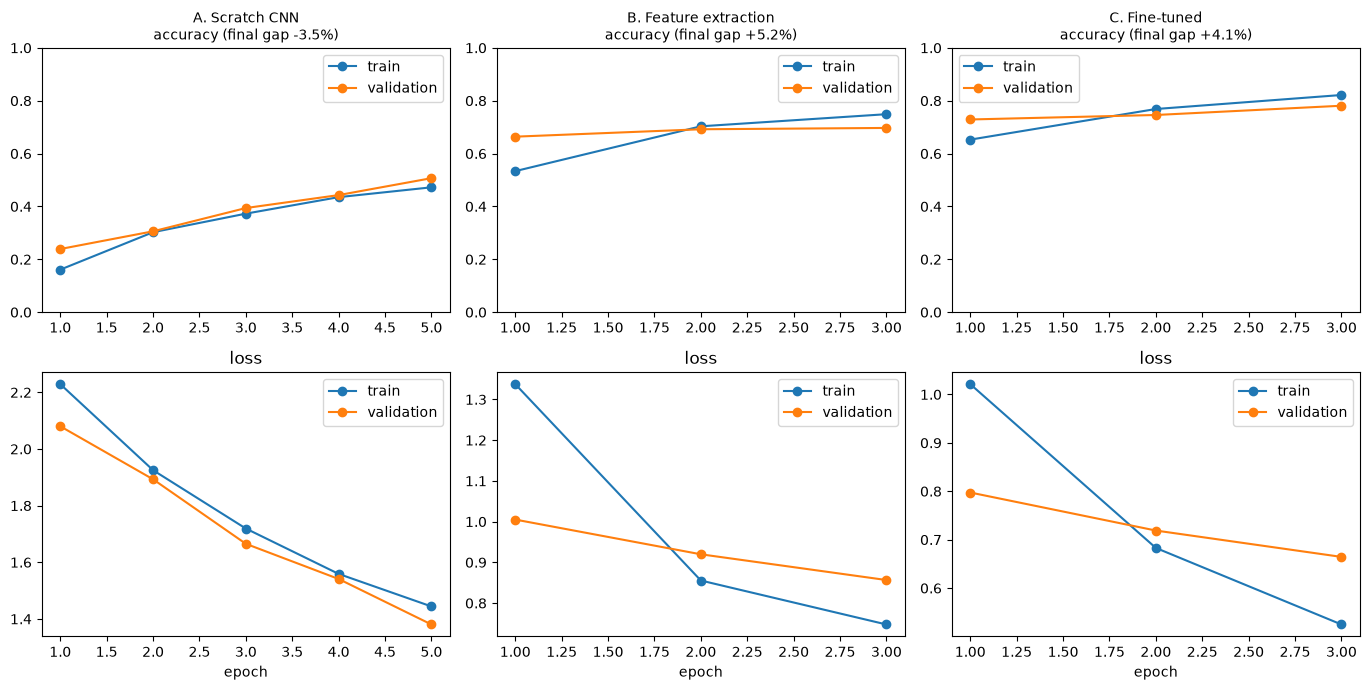

In [10]:
def plot_curves(hists):
    fig, axes = plt.subplots(
        2,
        len(hists),
        figsize=(4.6 * len(hists), 7),
        squeeze=False
    )

    for j, (name, h) in enumerate(hists.items()):

        e = range(
            1,
            len(h["val_acc"]) + 1
        )

        gap = (
            h["train_acc"][-1]
            - h["val_acc"][-1]
        )

        # Accuracy
        axes[0, j].plot(
            e,
            h["train_acc"],
            "o-",
            label="train"
        )

        axes[0, j].plot(
            e,
            h["val_acc"],
            "o-",
            label="validation"
        )

        axes[0, j].set_ylim(0, 1)
        axes[0, j].legend()

        axes[0, j].set_title(
            f"{name}\naccuracy "
            f"(final gap {gap:+.1%})",
            fontsize=10
        )

        # Loss
        axes[1, j].plot(
            e,
            h["train_loss"],
            "o-",
            label="train"
        )

        axes[1, j].plot(
            e,
            h["val_loss"],
            "o-",
            label="validation"
        )

        axes[1, j].set_xlabel("epoch")
        axes[1, j].set_title("loss")
        axes[1, j].legend()

    plt.tight_layout()
    plt.show()


plot_curves({
    "A. Scratch CNN": hist_scratch,
    "B. Feature extraction": hist_fe,
    "C. Fine-tuned": hist_ft
})

In [12]:
rows = [
    ("A. Scratch CNN", scratch, w3_test_loader, hist_scratch),
    ("B. Feature extraction", fe_model, test_loader, hist_fe),
    ("C. Fine-tuned ResNet-18", ft_model, test_loader, hist_ft)
]

print(f"{'Model':<26}{'trainable params':>18}{'val acc':>10}{'test acc':>10}")

test_acc = {}

for name, m, loader, h in rows:
    _, acc = run_epoch(m, loader)
    test_acc[name] = acc
    print(
        f"{name:<26}"
        f"{trainable(m):>18,}"
        f"{h['val_acc'][-1]:>10.1%}"
        f"{acc:>10.1%}"
    )

Model                       trainable params   val acc  test acc
A. Scratch CNN                       620,362     50.7%     49.6%
B. Feature extraction                  5,130     69.7%     71.4%
C. Fine-tuned ResNet-18            8,398,858     78.1%     77.1%


In [13]:
probs, ys = predict_all(ft_model, test_loader)

preds = probs.argmax(1)
cm = confusion(ys, preds)

prec = cm.diagonal() / np.maximum(cm.sum(0), 1)
rec = cm.diagonal() / np.maximum(cm.sum(1), 1)
f1 = 2 * prec * rec / np.maximum(prec + rec, 1e-9)

probs_s, ys_s = predict_all(scratch, w3_test_loader)

cm_s = confusion(ys_s, probs_s.argmax(1))
rec_s = cm_s.diagonal() / np.maximum(cm_s.sum(1), 1)

print(
    f"{'class':<11}"
    f"{'precision':>10}"
    f"{'recall':>8}"
    f"{'F1':>7}"
    f"{'recall (scratch)':>18}"
    f"{'gain':>8}"
)

for i, c in enumerate(CLASSES):
    print(
        f"{c:<11}"
        f"{prec[i]:>10.1%}"
        f"{rec[i]:>8.1%}"
        f"{f1[i]:>7.2f}"
        f"{rec_s[i]:>18.1%}"
        f"{rec[i] - rec_s[i]:>+8.1%}"
    )

print(f"\nmacro-F1 (fine-tuned): {f1.mean():.3f}")

off = cm.copy()
np.fill_diagonal(off, 0)

print("\nThree most common mistakes of the fine-tuned model:")

for idx in np.argsort(-off.ravel())[:3]:
    t, p_ = divmod(idx, len(CLASSES))
    print(
        f" {CLASSES[t]} predicted as {CLASSES[p_]}: "
        f"{off[t, p_]} times"
    )

class       precision  recall     F1  recall (scratch)    gain
airplane        73.9%   85.9%   0.79             44.6%  +41.3%
automobile      85.8%   83.9%   0.85             73.9%  +10.0%
bird            74.9%   67.7%   0.71             39.1%  +28.6%
cat             63.8%   60.4%   0.62             43.1%  +17.3%
deer            75.9%   65.9%   0.71             36.4%  +29.5%
dog             76.8%   66.7%   0.71             14.7%  +52.0%
frog            77.5%   82.8%   0.80             72.1%  +10.7%
horse           73.5%   85.8%   0.79             58.2%  +27.6%
ship            87.3%   85.6%   0.86             58.7%  +26.9%
truck           82.1%   86.8%   0.84             55.7%  +31.1%

macro-F1 (fine-tuned): 0.770

Three most common mistakes of the fine-tuned model:
 dog predicted as cat: 155 times
 cat predicted as dog: 121 times
 deer predicted as horse: 115 times


In [14]:
VEHICLES = torch.tensor([0, 1, 8, 9])  # airplane, automobile, ship, truck

true_v = torch.isin(ys, VEHICLES)
pred_v = torch.isin(preds, VEHICLES)

print(f"10-class (object-level) accuracy : {(preds == ys).float().mean():.2%}")
print(f"Vehicle vs animal (scene-level) : {(true_v == pred_v).float().mean():.2%}")

animal_as_vehicle = (
    ((~true_v) & pred_v).sum().item()
    / (~true_v).sum().item()
)

print(
    f"Animals mistaken for vehicles : "
    f"{animal_as_vehicle:.1%} <- the costly error for a deer warning"
)

10-class (object-level) accuracy : 77.15%
Vehicle vs animal (scene-level) : 96.19%
Animals mistaken for vehicles : 4.7% <- the costly error for a deer warning


In [15]:
def val_acc_with(transform):
    ds = torchvision.datasets.CIFAR10(
        root,
        train=True,
        download=False,
        transform=transform
    )

    loader = DataLoader(
        Subset(ds, val_idx),
        batch_size=128,
        shuffle=False,
        num_workers=2
    )

    return run_epoch(ft_model, loader)[1]


variants = {
    "ImageNet stats (correct)": T.Compose([
        T.Resize(IMG),
        T.ToTensor(),
        T.Normalize(IMNET_MEAN, IMNET_STD)
    ]),

    "CIFAR stats (close, wrong)": T.Compose([
        T.Resize(IMG),
        T.ToTensor(),
        T.Normalize(CIFAR_MEAN, CIFAR_STD)
    ]),

    "No normalisation (0..1)": T.Compose([
        T.Resize(IMG),
        T.ToTensor()
    ]),
}


for name, tf_ in variants.items():
    print(
        f"{name:<30} "
        f"validation accuracy = {val_acc_with(tf_):.1%}"
    )

ImageNet stats (correct)       validation accuracy = 78.1%
CIFAR stats (close, wrong)     validation accuracy = 76.9%
No normalisation (0..1)        validation accuracy = 47.2%


# Reflection

### 1. Transfer vs scratch

With only 5,000 labelled images, the pretrained models  outperformed the scratch CNN: feature extraction (B) achieved **71.4% test accuracy** and fine-tuning (C) achieved **77.1%**, compared with only **49.6%** for the scratch CNN.The pretrained ResNet-18 already learned useful image features from ImageNet, so it works better with less labelled data.
I would choose feature extraction (B) when the dataset is small and the pretrained features are already suitable, whereas I would choose fine-tuning (C) when the target dataset differs enough that adapting the pretrained features can improve performance.

### 2. Curves and regularisation

Model A had a final train/validation gap of −3.5%, while model C had a gap of +4.1%, so C had a larger train/validation gap.
Augmentation and dropout may have contributed to the difference, along with weight decay and the small learning rate, but their individual effects cannot be separated from a single run. I would test this by changing one method at a time and comparing the results.

### 3. Honest evaluation

I used the validation split to compare models and make model-selection decisions, while the test split was used only to report the final performance. Leakage could have occurred if the test set had been used to choose the model or tune hyperparameters, which would make the reported test accuracy overly optimistic. 
I would trust the system least on cats, because cat recall was the lowest at 60.4%, meaning the model correctly identified the smallest proportion of actual cat images.

# Think

### Question 1
**Why do we believe that the training and validation index lists do not overlap, and why is it important that the test set is never used while choosing between models? Name the pitfall that this protects you from.**

The training and validation indices are separate because they are created as **non-overlapping subsets** of the dataset. Keeping the test set out of model selection prevents **data leakage** and gives an unbiased estimate of the model’s final performance.

### Question 2
**The backbone has not changed at all, yet accuracy beats the scratch model's validation score using 0.05% of the parameters. What exactly is being reused?**

The model reuses the **pretrained ResNet-18 feature extractor**, including learned filters for edges, textures, shapes, and patterns from ImageNet. Only the final classifier is trained on the new dataset.

### Question 3
**We use horizontal flips but deliberately no vertical flips and no large rotations. For roadside scene recognition, why would those be unrealistic or harmful? Which augmentation would you add for night-time cameras?**

Vertical flips and large rotations are unrealistic because **roads, vehicles, and animals normally appear upright**, so these transformations could create unnatural scenes and confuse the model. For night-time cameras, I would add **brightness and contrast augmentation** to simulate darker and poorly lit conditions.

### Question 4
**Compare the recall column of the fine-tuned model with the scratch model. Which classes gained the most? Using Week 3's idea of edges → textures → parts → objects, why might pretrained features help most for those classes? And why is overall accuracy alone not enough to decide whether the system is safe to deploy?**

The biggest recall gains were for **dog (+52.0%)**, **airplane (+41.3%)**, and **deer (+29.5%)**. Pretrained features already capture useful **edges, textures, and shapes/parts**, helping the model recognise complex objects more effectively. Overall accuracy is not enough because a model can have high accuracy while still performing poorly on an important class, such as **deer**, which matters for a safe roadside warning system.